<a href="https://colab.research.google.com/github/ThangallapallyHasini/2273-Natural-Language/blob/main/2273_nlp_10_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install gensim

In [3]:
# ================================
# Loading Pre-trained Embeddings
# ================================
from gensim.models import KeyedVectors
import gensim.downloader as api

# ================================
# Handling Matrices & Numerical Operations
# ================================
import numpy as np

# ================================
# Visualization
# ================================
import matplotlib.pyplot as plt

# ================================
# t-SNE for Dimensionality Reduction
# ================================
from sklearn.manifold import TSNE

In [4]:
# Load pre-trained Word2Vec model (may take time on first download)
model_word2vec = api.load("word2vec-google-news-300")
model_glove = api.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 1662.8/1662.8MB downloaded
[==================================================] 100.0% 128.1/128.1MB downloaded


In [5]:
word_list = [

    # Emotions
    "happiness", "anger", "fear", "surprise", "sadness",

    # Weather
    "rain", "snow", "storm", "wind", "cloud",

    # Food
    "pizza", "bread", "rice", "apple", "cheese",

    # Sports
    "football", "cricket", "tennis", "basketball", "hockey",

    # Music
    "guitar", "piano", "drum", "violin", "flute",

    # Space
    "planet", "star", "galaxy", "asteroid", "comet",

    # Professions
    "engineer", "artist", "chef", "pilot", "lawyer",

    # Household Items
    "table", "chair", "mirror", "window", "door"
]

In [6]:
vectors = [model_word2vec[word] for word in word_list if word in model_word2vec]

# Convert to NumPy array
vectors_word2vec = np.array(vectors)

print("Total selected words:", len(word_list))
print("Vector shape:", vectors_word2vec.shape)
print(vectors_word2vec[0])

Total selected words: 40
Vector shape: (40, 300)
[ 0.27148438 -0.13183594  0.12890625  0.22070312  0.25585938 -0.05908203
  0.26757812 -0.23828125  0.23828125 -0.0168457  -0.11132812 -0.15625
  0.13769531  0.50390625 -0.29882812  0.359375    0.34375     0.3125
 -0.03369141 -0.19433594 -0.06103516 -0.02844238 -0.01672363  0.20410156
  0.04858398 -0.06787109 -0.18457031  0.06591797  0.07177734  0.03271484
 -0.25       -0.26171875  0.00579834  0.07910156 -0.28515625 -0.08056641
  0.0402832   0.08544922 -0.13085938  0.08398438 -0.0402832   0.09863281
 -0.25390625  0.0546875   0.20605469 -0.21484375  0.13769531  0.28515625
 -0.10986328 -0.02526855 -0.23339844  0.29296875 -0.11328125  0.10693359
  0.08740234 -0.21582031 -0.3828125  -0.22753906 -0.16992188 -0.05957031
  0.203125    0.08691406  0.06542969  0.30078125  0.07568359  0.10986328
 -0.20214844 -0.01519775 -0.00662231  0.13085938  0.0234375  -0.18457031
  0.15039062  0.03735352 -0.08935547 -0.32421875 -0.28125    -0.00701904
  0.01721

In [7]:
vectors = [model_glove[word] for word in word_list if word in model_glove]

# Convert to NumPy array
vectors_glove = np.array(vectors)

print("Total selected words:", len(word_list))
print("Vector shape:", vectors_glove.shape)
print(vectors_glove[0])

Total selected words: 40
Vector shape: (40, 100)
[ 0.34787   0.51698   0.68826   0.46672   0.23281   0.24939  -0.3056
 -0.66775   0.33853  -0.4138   -0.26491   0.81739   0.1647   -0.020416
 -0.30255  -0.35699  -0.035811  0.60566  -0.65723   0.52597  -0.096687
 -0.18564  -0.68472  -0.3169    0.35202   0.86957   0.36218  -0.34896
  0.27325  -0.79375  -0.41767   0.25992  -0.22309   0.33138   0.23931
  0.19088   0.43871   0.94906  -0.34136  -0.79913  -0.14859  -0.083507
 -0.19188  -0.27698  -0.22126  -0.36107   0.13269   0.20514  -0.1995
 -0.51745  -0.034291 -0.4948    0.17619   0.91049   0.25434  -1.1916
  0.72422   0.48084   0.23335  -0.40026   0.088955  0.44969  -0.57187
 -0.9131    0.2241    0.61892   0.74713  -0.97972   0.62982  -0.54524
  0.14303   0.18413   0.25842  -0.36798   0.51768   1.3952    0.12726
 -0.9476   -0.73982  -0.045384 -0.69598   1.1689    0.41988   0.10135
 -0.7905    0.16056   0.23655  -0.64644  -0.34583  -0.20215  -0.21999
 -0.11761   0.4683    0.28577  -0.17052  

In [8]:
# Assume vectors already extracted from previous step
# vectors shape example: (40, 100)

# Apply t-SNE
tsne = TSNE(
    n_components=2,      # Reduce to 2D
    random_state=42,
    perplexity=10,
    learning_rate=200
)

tsne_coordinates = tsne.fit_transform(vectors_word2vec)

# Store results
print("Original Shape:", vectors_word2vec.shape)
print("Reduced Shape:", tsne_coordinates.shape)

# Display first 5 coordinates
print("\nFirst 5 t-SNE Coordinates:")
print(tsne_coordinates[:5])
# Display first 5 coordinates of word2vec
print("\nFirst 5 t-SNE Coordinates:")
print(vectors_word2vec[:5])

Original Shape: (40, 300)
Reduced Shape: (40, 2)

First 5 t-SNE Coordinates:
[[109.131905 102.1971  ]
 [118.51251   58.926586]
 [ 97.38396   65.52722 ]
 [ 72.8817    54.48146 ]
 [133.16637   85.91762 ]]

First 5 t-SNE Coordinates:
[[ 0.27148438 -0.13183594  0.12890625 ... -0.02294922  0.11376953
  -0.13183594]
 [ 0.27539062  0.02319336  0.10205078 ...  0.04174805  0.04150391
   0.04296875]
 [ 0.19824219  0.01544189  0.10888672 ... -0.17089844  0.13964844
   0.07226562]
 [ 0.02575684 -0.06542969  0.16210938 ...  0.12695312  0.08642578
  -0.0098877 ]
 [ 0.31445312 -0.06005859  0.17480469 ... -0.11914062  0.00280762
  -0.15820312]]


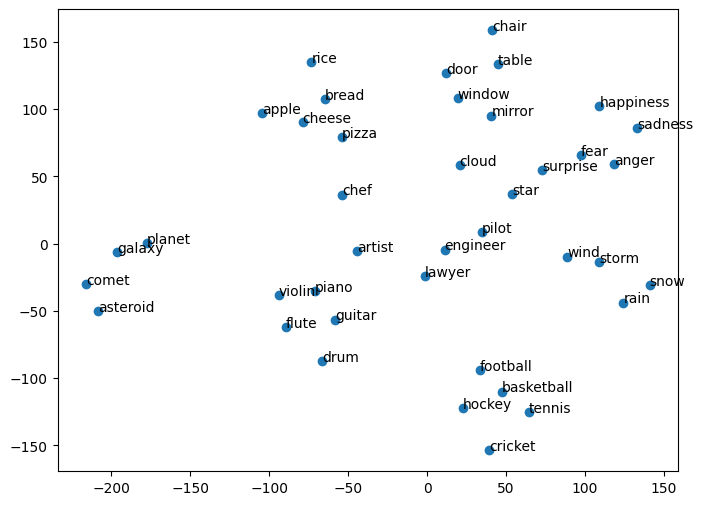

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(tsne_coordinates[:,0], tsne_coordinates[:,1])

for i, word in enumerate(word_list):
    plt.annotate(word, (tsne_coordinates[i,0], tsne_coordinates[i,1]))

plt.show()

In [10]:
# Assume vectors already extracted from previous step
# vectors shape example: (40, 100)

# Apply t-SNE
tsne = TSNE(
    n_components=2,      # Reduce to 2D
    random_state=42,
    perplexity=10,
    learning_rate=200
)

tsne_coordinates = tsne.fit_transform(vectors_glove)

# Store results
print("Original Shape:", vectors_glove.shape)
print("Reduced Shape:", tsne_coordinates.shape)

# Display first 5 coordinates
print("\nFirst 5 t-SNE Coordinates:")
print(tsne_coordinates[:5])
# Display first 5 coordinates of glove
print("\nFirst 5 t-SNE Coordinates:")
print(vectors_glove[:5])

Original Shape: (40, 100)
Reduced Shape: (40, 2)

First 5 t-SNE Coordinates:
[[-79.63023    -40.933983  ]
 [-75.132706    -0.64654696]
 [-52.223637    -6.4169774 ]
 [-37.12972    -32.2263    ]
 [-94.80107    -19.230392  ]]

First 5 t-SNE Coordinates:
[[ 3.4787e-01  5.1698e-01  6.8826e-01  4.6672e-01  2.3281e-01  2.4939e-01
  -3.0560e-01 -6.6775e-01  3.3853e-01 -4.1380e-01 -2.6491e-01  8.1739e-01
   1.6470e-01 -2.0416e-02 -3.0255e-01 -3.5699e-01 -3.5811e-02  6.0566e-01
  -6.5723e-01  5.2597e-01 -9.6687e-02 -1.8564e-01 -6.8472e-01 -3.1690e-01
   3.5202e-01  8.6957e-01  3.6218e-01 -3.4896e-01  2.7325e-01 -7.9375e-01
  -4.1767e-01  2.5992e-01 -2.2309e-01  3.3138e-01  2.3931e-01  1.9088e-01
   4.3871e-01  9.4906e-01 -3.4136e-01 -7.9913e-01 -1.4859e-01 -8.3507e-02
  -1.9188e-01 -2.7698e-01 -2.2126e-01 -3.6107e-01  1.3269e-01  2.0514e-01
  -1.9950e-01 -5.1745e-01 -3.4291e-02 -4.9480e-01  1.7619e-01  9.1049e-01
   2.5434e-01 -1.1916e+00  7.2422e-01  4.8084e-01  2.3335e-01 -4.0026e-01
   8.8955

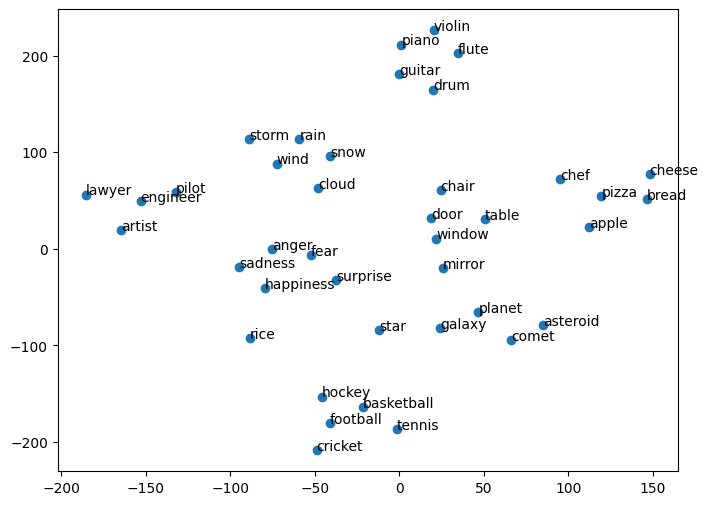

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(tsne_coordinates[:,0], tsne_coordinates[:,1])

for i, word in enumerate(word_list):
    plt.annotate(word, (tsne_coordinates[i,0], tsne_coordinates[i,1]))

plt.show()